<a href="https://colab.research.google.com/github/alpacaYiChun/ML/blob/master/SearchImage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
# === Colab single cell: search images in Google Drive by text prompt ===

!pip -q install transformers pillow tqdm matplotlib

import os
from pathlib import Path
from PIL import Image, UnidentifiedImageError
import torch
from transformers import CLIPProcessor, CLIPModel
from google.colab import drive
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# ---------------------------
# 1) User settings
# ---------------------------
ROOT_FOLDER = "/content/drive/MyDrive/publicstatic"   # <-- change this

TOP_K = 12
BATCH_SIZE = 16
RECURSIVE = True

# Allowed image types
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".gif"}

# ---------------------------
# 2) Mount Drive
# ---------------------------
drive.mount("/content/drive")

# ---------------------------
# 3) Collect image paths
# ---------------------------
root = Path(ROOT_FOLDER)
if not root.exists():
    raise FileNotFoundError(f"Folder not found: {ROOT_FOLDER}")

if RECURSIVE:
    image_paths = [p for p in root.rglob("*") if p.suffix.lower() in IMAGE_EXTS]
else:
    image_paths = [p for p in root.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTS]

if not image_paths:
    raise ValueError(f"No images found under: {ROOT_FOLDER}")

print(f"Found {len(image_paths)} images.")

# ---------------------------
# 4) Load CLIP
# ---------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "openai/clip-vit-base-patch32"

model = CLIPModel.from_pretrained(model_name).to(device)
processor = CLIPProcessor.from_pretrained(model_name)
model.eval()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 3799 images.


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,

In [1]:
# ---------------------------
# 5) Encode images
# ---------------------------
def load_valid_image(path):
    try:
        img = Image.open(path).convert("RGB")
        return img
    except (UnidentifiedImageError, OSError):
        return None

valid_paths = []
valid_images = []

for p in tqdm(image_paths, desc="Loading images"):
    img = load_valid_image(p)
    if img is not None:
        valid_paths.append(str(p))
        valid_images.append(img)

if not valid_images:
    raise ValueError("No valid readable images found.")



Mounted at /content/drive
Found 3799 images.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Loading images:   0%|          | 0/3799 [00:00<?, ?it/s]

In [2]:
all_img_embeds = []

for i in tqdm(range(0, len(valid_images), BATCH_SIZE), desc="Encoding images"):
    batch_imgs = valid_images[i:i + BATCH_SIZE]
    inputs = processor(images=batch_imgs, return_tensors="pt").to(device)

    with torch.no_grad():
        feats = model.get_image_features(**inputs)       # or pixel_values=inputs["pixel_values"]
        if not isinstance(feats, torch.Tensor):
            feats = feats.image_embeds if hasattr(feats, "image_embeds") else feats.pooler_output
        feats = feats / feats.norm(dim=-1, keepdim=True)

    all_img_embeds.append(feats.cpu())

image_embeds = torch.cat(all_img_embeds, dim=0)

Encoding images:   0%|          | 0/238 [00:00<?, ?it/s]

In [6]:
save_dir = "/content/drive/MyDrive/clip_embeddings"
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, "image_embeds.pt")
torch.save(image_embeds, save_path)

print(f"Saved to: {save_path}")
print(f"Shape: {tuple(image_embeds.shape)}")
print(f"Dtype: {image_embeds.dtype}")

Saved to: /content/drive/MyDrive/clip_embeddings/image_embeds.pt
Shape: (3799, 512)
Dtype: torch.float32


In [8]:
import torch

load_path = "/content/drive/MyDrive/clip_embeddings/image_embeds.pt"
image_embeds = torch.load(load_path, map_location="cpu")

print(f"Loaded from: {load_path}")
print(f"Shape: {tuple(image_embeds.shape)}")
print(f"Dtype: {image_embeds.dtype}")

Loaded from: /content/drive/MyDrive/clip_embeddings/image_embeds.pt
Shape: (3799, 512)
Dtype: torch.float32



Top matches:
 1. score=0.2737  path=/content/drive/MyDrive/publicstatic/IMAG1645.jpg
 2. score=0.2722  path=/content/drive/MyDrive/publicstatic/IMAG0326.jpg
 3. score=0.2706  path=/content/drive/MyDrive/publicstatic/IMAG0325.jpg
 4. score=0.2697  path=/content/drive/MyDrive/publicstatic/IMAG1134.jpg
 5. score=0.2697  path=/content/drive/MyDrive/publicstatic/IMG_20180129_201933.jpg
 6. score=0.2666  path=/content/drive/MyDrive/publicstatic/IMG_20180115_091703.jpg
 7. score=0.2635  path=/content/drive/MyDrive/publicstatic/IMAG0556.jpg
 8. score=0.2622  path=/content/drive/MyDrive/publicstatic/IMAG1431.jpg
 9. score=0.2620  path=/content/drive/MyDrive/publicstatic/IMAG1410.jpg
10. score=0.2616  path=/content/drive/MyDrive/publicstatic/IMAG0548.jpg
11. score=0.2566  path=/content/drive/MyDrive/publicstatic/IMAG0482.jpg
12. score=0.2564  path=/content/drive/MyDrive/publicstatic/IMAG0860.jpg


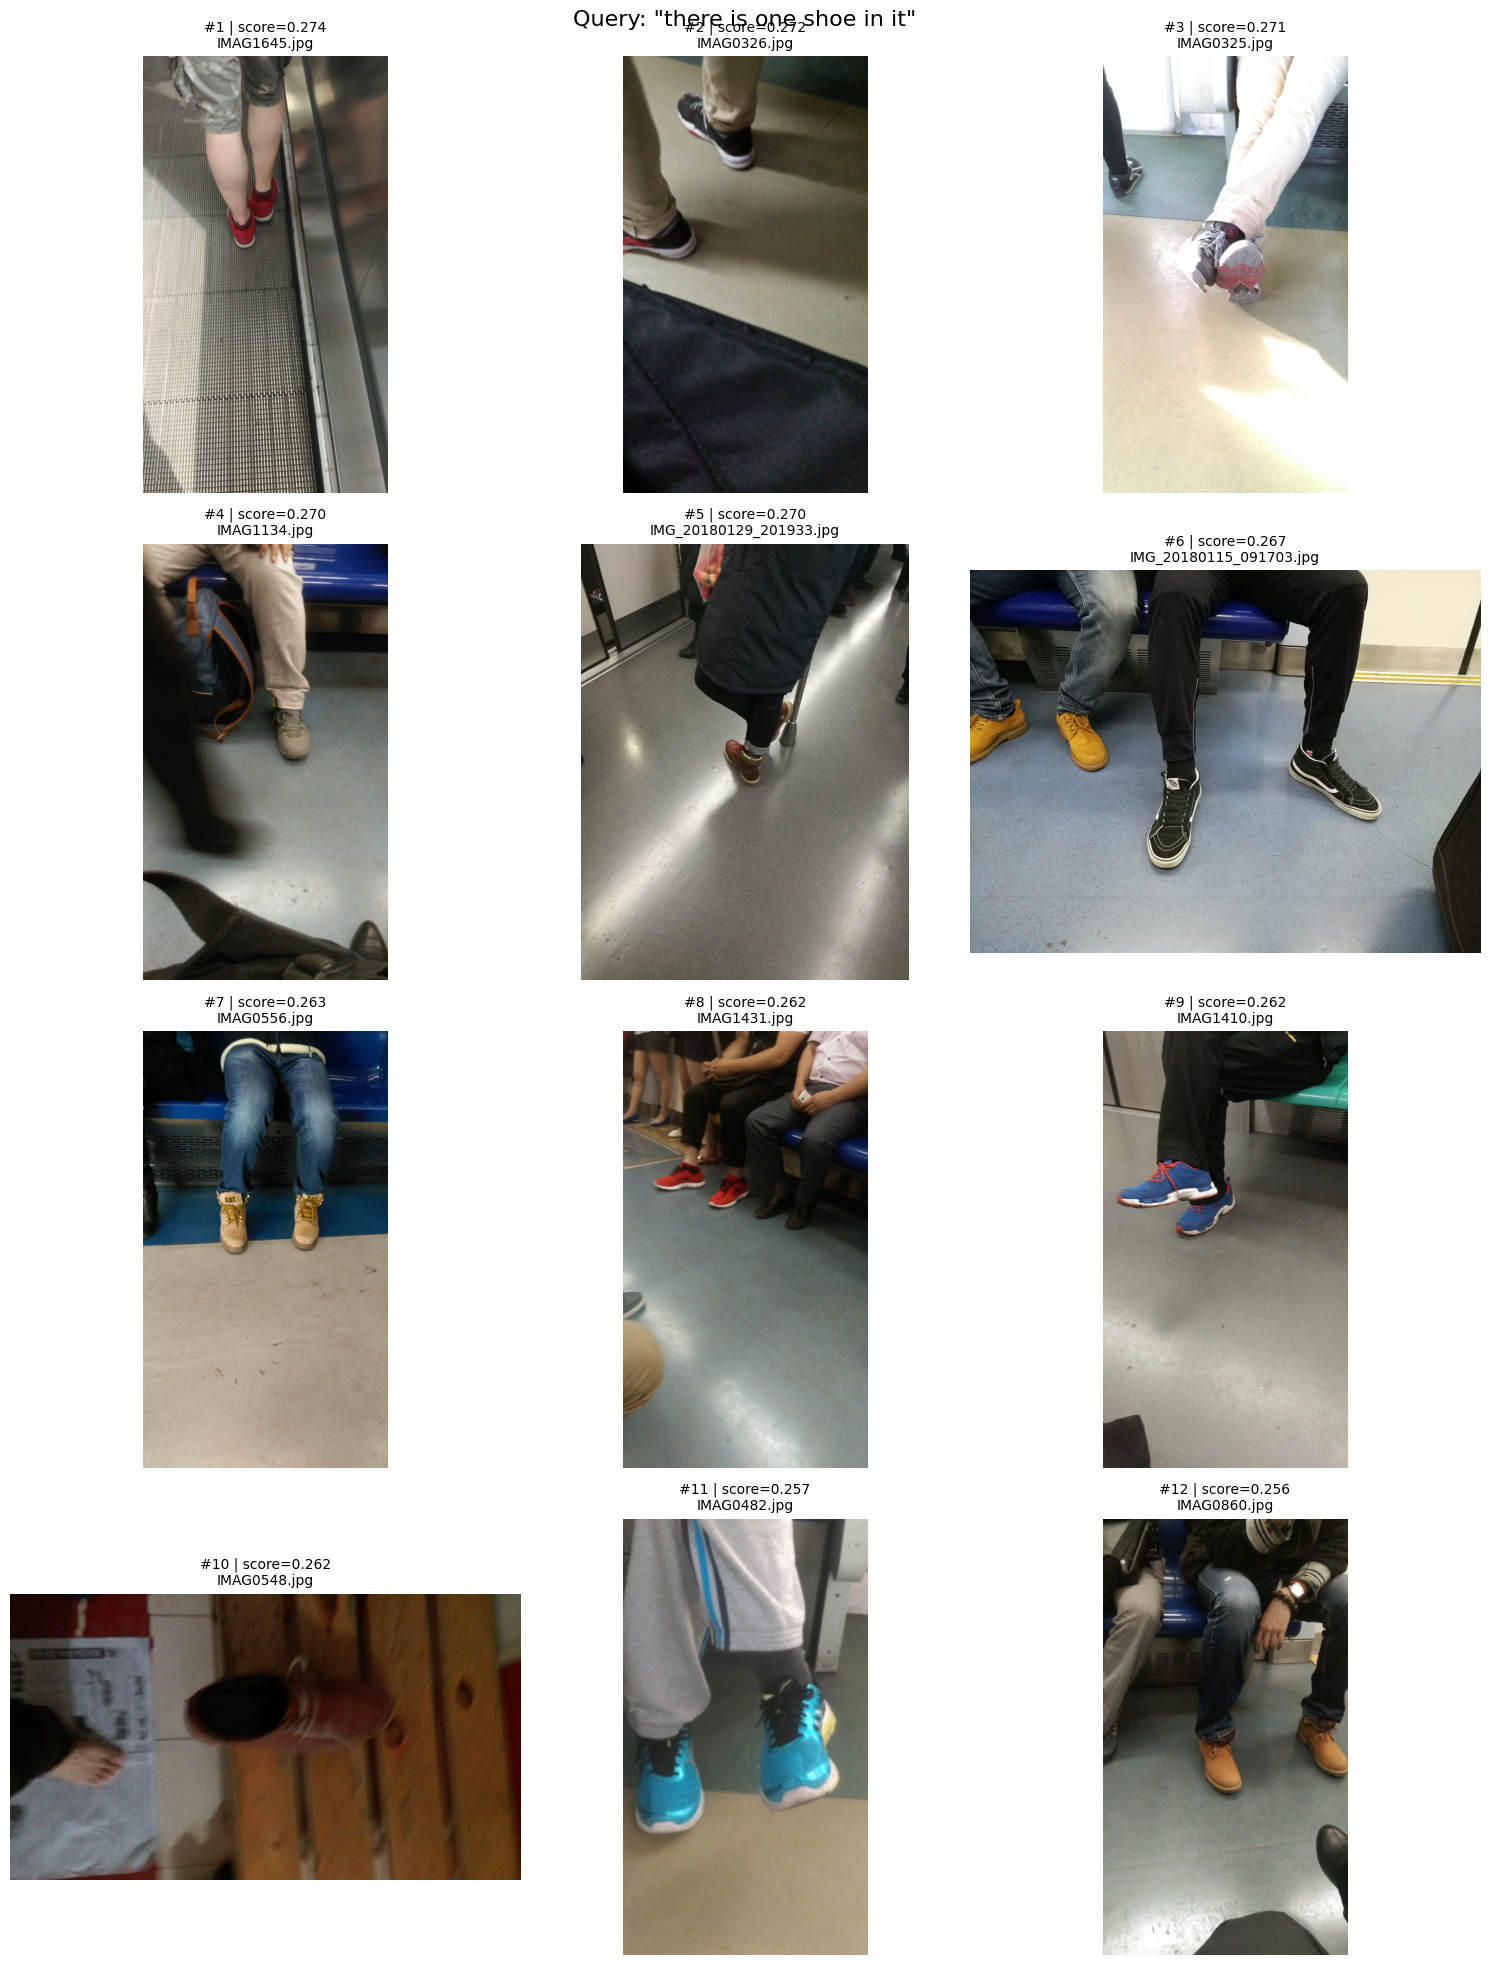

In [10]:
TEXT_QUERY = "there is one shoe in it"

# ---------------------------
# 6) Encode text query
# ---------------------------
text_inputs = processor(text=[TEXT_QUERY], return_tensors="pt", padding=True, truncation=True).to(device)

with torch.no_grad():
    outputs = model.text_model(
        input_ids=text_inputs["input_ids"],
        attention_mask=text_inputs["attention_mask"],
    )
    text_embed = outputs.pooler_output              # [1, D]
    text_embed = model.text_projection(text_embed) # project to shared embedding space
    text_embed = text_embed / text_embed.norm(dim=-1, keepdim=True)

text_embed = text_embed.cpu()   # [1, D]

# ---------------------------
# 7) Similarity + top results
# ---------------------------
scores = (image_embeds @ text_embed.T).squeeze(1)
top_k = min(TOP_K, len(valid_paths))
top_scores, top_indices = torch.topk(scores, k=top_k)

results = [(valid_paths[idx], float(top_scores[i])) for i, idx in enumerate(top_indices.tolist())]

print("\nTop matches:")
for rank, (path, score) in enumerate(results, 1):
    print(f"{rank:2d}. score={score:.4f}  path={path}")

# ---------------------------
# 8) Display results
# ---------------------------
cols = 3
rows = (top_k + cols - 1) // cols
plt.figure(figsize=(5 * cols, 5 * rows))

for i, (path, score) in enumerate(results, 1):
    img = Image.open(path).convert("RGB")
    plt.subplot(rows, cols, i)
    plt.imshow(img)
    plt.title(f"#{i} | score={score:.3f}\n{os.path.basename(path)}", fontsize=10)
    plt.axis("off")

plt.suptitle(f'Query: "{TEXT_QUERY}"', fontsize=16)
plt.tight_layout()
plt.show()